# Decision Analysis — Selecting the Threshold / Cost / SHAP of the Main Model

Perform pre-deployment analysis on the Winner Model. Run `02_train.py`, `03_compare.py`, and `04_decision.py` first.

The model in `reports/winner.txt` is used by default; you can manually change `MODEL_NAME` below.

## 0. Import + Select Model + Load its Cache Predictions

In [ ]:
%matplotlib inline
import sys
from pathlib import Path
HERE = Path.cwd()
SCRIPTS = HERE / "scripts" if (HERE / "scripts").exists() else HERE.parent / "scripts"
sys.path.append(str(SCRIPTS))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sba_common import (load_predictions, preds_path, WINNER_FILE, decision_report)

# The default read/write winner; modify this section if you want to analyze other models.
MODEL_NAME = WINNER_FILE.read_text(encoding="utf-8").strip() if WINNER_FILE.exists() else "catboost"
print("Analysis model:", MODEL_NAME)

pred = load_predictions(MODEL_NAME)
y_true = pred["y_true"].to_numpy()
proba = pred["proba"].to_numpy()
print("test default rate:", round(y_true.mean(), 4))

分析模型: catboost
test default rate: 0.3243


## 1. Loan Disbursement Threshold / Decision Curve ← FYP Core Chart

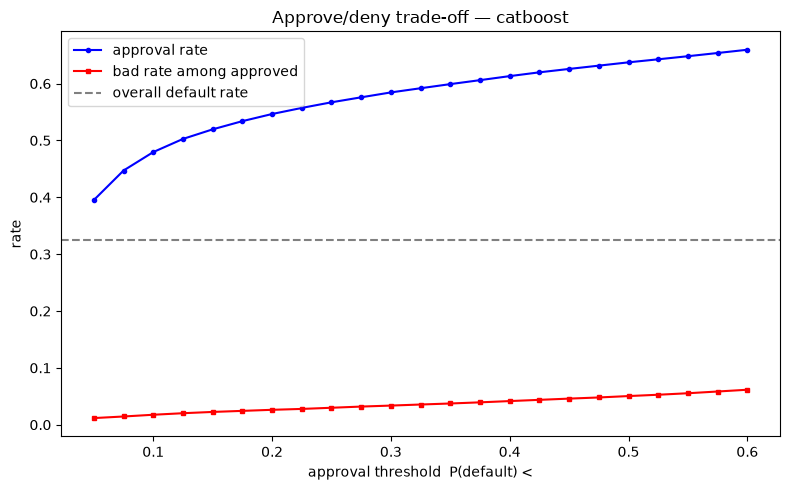

,threshold,approval_rate,bad_rate_approved,default_recall
0,0.050,0.3952,0.0117,0.9857
1,0.075,0.4471,0.0145,0.9800
2,0.100,0.4795,0.0176,0.9740
3,0.125,0.5026,0.0203,0.9686
4,0.150,0.5195,0.0225,0.9639
5,0.175,0.5339,0.0244,0.9599
6,0.200,0.5465,0.0263,0.9558
7,0.225,0.5572,0.0278,0.9522
8,0.250,0.5671,0.0299,0.9478
9,0.275,0.5758,0.0319,0.9433


In [2]:
rows = [decision_report(y_true, proba, t) for t in np.linspace(0.05, 0.60, 23)]
curve = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve["threshold"], curve["approval_rate"], "b-o", ms=3, label="approval rate")
ax.plot(curve["threshold"], curve["bad_rate_approved"], "r-s", ms=3, label="bad rate among approved")
ax.axhline(y_true.mean(), ls="--", color="grey", label="overall default rate")
ax.set_xlabel("approval threshold  P(default) <"); ax.set_ylabel("rate")
ax.set_title(f"Approve/deny trade-off — {MODEL_NAME}"); ax.legend()
plt.tight_layout(); plt.show()
curve.round(4)

## 2. Optimal Cost Threshold

Assume the loss from letting a defaulter go is equal to the `COST_RATIO` times the loss from wrongly rejecting a good customer. This ratio should be set according to your business needs and stated in your reports.

COST_RATIO=5.0 -> 最优阈值 ≈ 0.310
{'threshold': np.float64(0.31005025125628144), 'approval_rate': 0.5875815285186461, 'bad_rate_approved': 0.034281266111992885, 'default_recall': 0.9378914978570644}


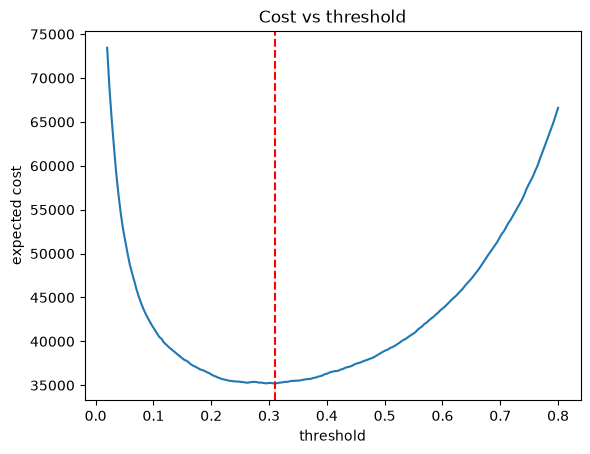

In [ ]:
COST_RATIO = 5.0
ths = np.linspace(0.02, 0.8, 200)
costs = [COST_RATIO * ((y_true == 1) & (proba < t)).sum() + ((y_true == 0) & (proba >= t)).sum()
         for t in ths]
best_t = ths[int(np.argmin(costs))]
print(f"COST_RATIO={COST_RATIO} -> Optimal threshold ≈ {best_t:.3f}")
print(decision_report(y_true, proba, best_t))

plt.plot(ths, costs); plt.axvline(best_t, ls="--", color="red")
plt.xlabel("threshold"); plt.ylabel("expected cost"); plt.title("Cost vs threshold"); plt.show()

## 3. SHAP — Feature Contribution (XAI)

SHAP is retrieved based on the winner model type (the three libraries use different methods, which will be automatically assigned below). `pip install shap` is required.

The preprocessing used to reconstruct the test set features is exactly the same as that used during training.

In [ ]:
import shap
import joblib
from sba_common import model_path, load_clean, temporal_split, get_feature_setup, build_xy, to_category

model = joblib.load(model_path(MODEL_NAME))
df = load_clean()
_, _, test_df = temporal_split(df, verbose=False)
fcols, cats = get_feature_setup(df)
X_test, y_test = build_xy(test_df, fcols, cats)

# Retrieve SHAP values ​​by model type (using the native methods of each library, the most stable approach)
if MODEL_NAME == "catboost":
    from catboost import Pool
    shap_vals = model.get_feature_importance(Pool(X_test, y_test, cat_features=cats),
                                             type="ShapValues")[:, :-1]
    X_disp = X_test
else:
    X_cat = to_category([X_test], cats)[0]
    if MODEL_NAME == "lightgbm":
        shap_vals = model.predict(X_cat, pred_contrib=True)[:, :-1]
    else:  # xgboost
        import xgboost as xgb
        dm = xgb.DMatrix(X_cat, enable_categorical=True)
        shap_vals = model.get_booster().predict(dm, pred_contribs=True)[:, :-1]
    X_disp = X_cat

print("shap_values:", shap_vals.shape)

c:\Users\USER\Downloads\credit_sme\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap_values: (168346, 19)


### 3a. Global Importance (mean |SHAP|) – The most stable single XAI image

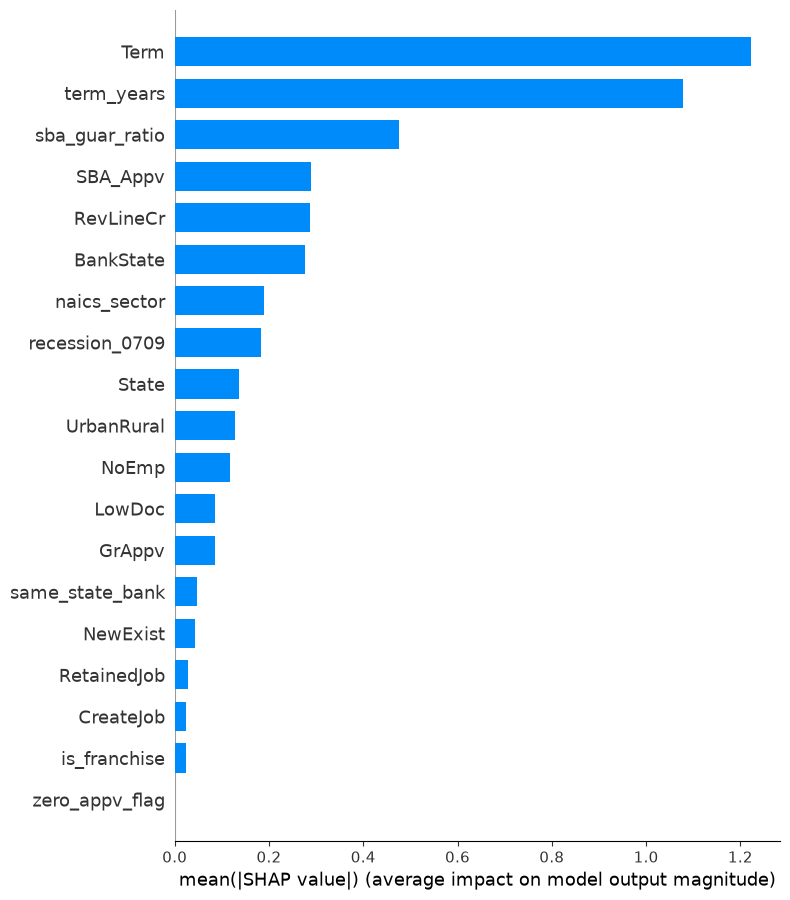

In [5]:
shap.summary_plot(shap_vals, feature_names=fcols, plot_type="bar", show=True)

### 3b. Beeswarm (Category columns are colored by code, for distribution reference only)

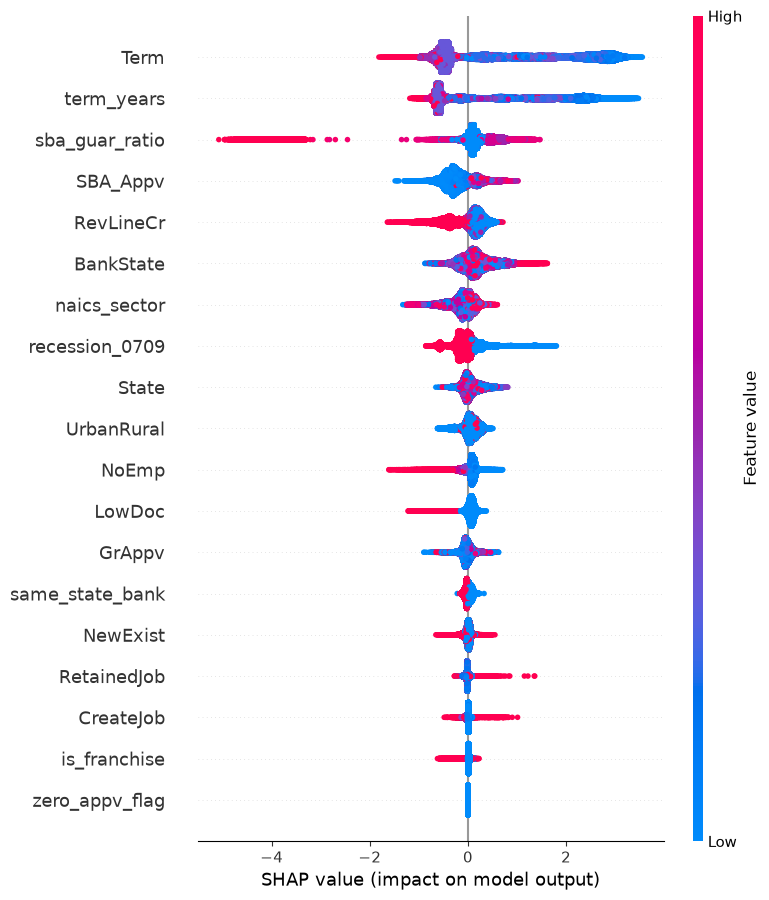

In [6]:
X_num = X_disp.copy()
for col in cats:
    X_num[col] = X_disp[col].astype("category").cat.codes
shap.summary_plot(shap_vals, X_num, feature_names=fcols, show=True)

## 4. Summary

- The threshold/cost curve reads the cached prediction; **changing models only requires modifying `MODEL_NAME` in Section 0**, no retraining is needed.

- SHAP is automatically assigned based on model type, supported by all three libraries.

- The report clearly explains "why this threshold (cost assumption) was chosen" and "which features SHAP shows drive default,"

thus explaining the decision-making logic and interpretability.